# ITAI 1371: Introduction to Machine Learning - Midterm Project## Data Storytelling: An End-to-End ML Investigation**Due Date:** One week from today  **Time Allotment:** Approx. 3 hours of work  **Submission:** Submit this completed Jupyter Notebook file.---### Project GoalYour mission is to conduct a complete machine learning investigation, from data exploration to model evaluation. More than just writing code, you will be a **data storyteller**. Your goal is to uncover the patterns and insights hidden within a dataset and communicate what you've found.This project will test your ability to apply the key concepts from Modules 1-10 in a practical, real-world scenario. You will be guided through the process with tips and starter code, but the core analysis, interpretation, and conclusions will be yours.### Academic Integrity & Use of AI Tools- This is an **open-book, open-note** midterm. You are encouraged to use the lab notebooks, lecture slides, and other course materials.- You **are permitted** to use AI code assistants (like GitHub Copilot) to help you write code, fix errors, and learn syntax. This is a valuable real-world skill.- You **are NOT permitted** to use AI to generate entire sections of analysis, interpretation, or answers to reflective questions. The goal is for *you* to demonstrate understanding.**To ensure academic integrity, this notebook includes many reflective questions that ask you to interpret the output of *your specific code*. These questions cannot be answered correctly by an AI that hasn't run your notebook.**---### Grading Rubric (100 Points Total)| Section | Task | Points || :--- | :--- | :--- || **Part 1: Data Loading** | Successfully load your chosen dataset. | 5 || **Part 2: EDA** | Create and interpret at least two relevant visualizations. | 20 || | Write a clear interpretation of the story your plots tell. | || **Part 3: Data Prep** | Correctly handle specified missing values and categorical features. | 15 || | Justify your choices in the markdown cells. | || **Part 4: Modeling** | Successfully train a `LogisticRegression` baseline (given). | 15 || | Successfully train a second model of your choice. | || **Part 5: Evaluation** | Calculate and compare accuracy for both models. | 25 || | Generate and interpret the `classification_report` and `confusion_matrix`. | || | Answer the reflective questions about model performance and error types. | || **Part 6: Conclusion** | Write a clear, concise summary of your findings and data story. | 15 || | Address the key questions in the conclusion prompt. | || **Overall** | Code is clean, commented, and runs without errors. All markdown cells are filled out. | 5 |

## Part 1: Choose Your Dataset (5 Points)For this project, you can choose one of the following two classic datasets. Both are classification problems.1.  **Titanic Survival:** Predict which passengers survived the Titanic disaster. (You are familiar with this from our lab).2.  **Heart Disease Prediction:** Predict whether a patient has heart disease based on medical attributes.**Instructions:**1.  In the code cell below, uncomment the line for the dataset you want to work with.2.  Run the cell to load the data into a pandas DataFrame called `df`.3.  Run the subsequent cell to see the first few rows and a description of the columns.

In [1]:
import pandas as pd
import numpy as np

# Titanic Dataset
dataset_url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"

df = pd.read_csv(dataset_url)

print(df.head())

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  


### Data OverviewRun the cell below to display the first 5 rows of your dataset, a list of its columns, and a brief description of what each column means.

In [2]:
# Display the first 5 rows of the dataframe
print("--- First 5 Rows ---")
print(df.head())

# Display column info and descriptions
print("--- Column Descriptions ---")

if 'PassengerId' in df.columns:
    print("You are using the Titanic Dataset.")
    print("Target Variable: 'Survived' (0 = No, 1 = Yes)")
else:
    print("You are using the Heart Disease Dataset.")
    print("Target Variable: 'target' (0 = No Heart Disease, 1 = Has Heart Disease)")

# Rename heart disease columns for clarity
if 'cp' in df.columns:
    df = df.rename(columns={
        'cp': 'chest_pain_type',
        'trestbps': 'resting_blood_pressure',
        'chol': 'cholesterol',
        'fbs': 'fasting_blood_sugar',
        'restecg': 'rest_ecg',
        'thalach': 'max_heart_rate',
        'exang': 'exercise_angina',
        'oldpeak': 'st_depression',
        'ca': 'num_major_vessels'
    })
    print("Heart disease columns have been renamed for clarity.")

print("--- Data Info ---")
df.info()

--- First 5 Rows ---
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.050

## Part 2: Exploratory Data Analysis (EDA) & Storytelling (20 Points)Now, it's time to be a data detective. Before you can model the data, you must understand it. What secrets does it hold?**Your Task:**1.  **Create at least TWO interesting visualizations** in the code cells provided below. You can create more if you like.    *   Use libraries like `matplotlib` or `seaborn`.    *   Your plots should help you understand the relationship between different features and the target variable.    *   **Tip:** Think about the questions we asked during the Titanic lab (e.g., "How does survival rate differ by gender?" or "What is the age distribution of survivors?"). Ask similar questions of your dataset.2.  **Interpret your visualizations** in the markdown cell provided. Explain what you see and what story your plots are starting to tell.

### Visualization 1**Instructions:** Create your first plot in the cell below. Make sure to give it a title and label your axes! Good plots are easy to read.

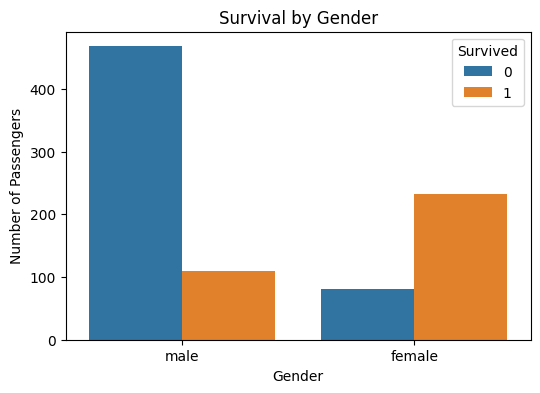

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.countplot(data=df, x='Sex', hue='Survived')
plt.title("Survival by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Passengers")
plt.show()

### Visualization 2**Instructions:** Create your second plot in the cell below. Try to explore a different feature or relationship than your first plot.

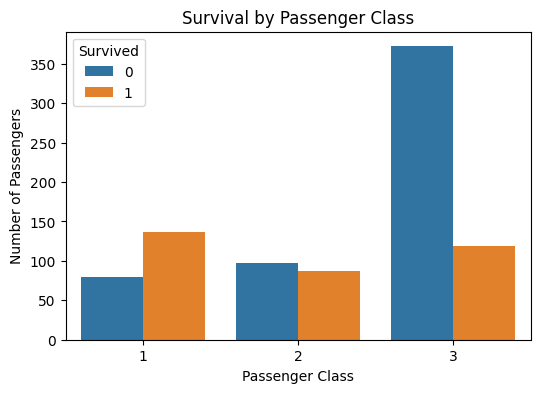

In [4]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='Pclass', hue='Survived')
plt.title("Survival by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Number of Passengers")
plt.show()

### Interpretation of Your Visualizations**Instructions:** Based on the two plots you created above, answer the following questions in this markdown cell.1.  **What did you plot?** (Briefly describe your two visualizations).2.  **What story do your plots tell?** (What initial insights or patterns did you discover? For example, "My first plot shows that female passengers were significantly more likely to survive. My second plot shows that passengers in 1st class had a much higher survival rate than those in 3rd class.")3.  **What is one hypothesis you can form based on your EDA?** (e.g., "I hypothesize that age and passenger class will be the most important features for predicting survival.")**--- ENTER YOUR ANSWERS BELOW ---**
1. My first plot compares passenger survival based on gender. It shows that the female passengers had a much higher survival rate than the male passengers. Despite there being more male passengers on the Titanic, a significantly larger proportion of women survived. This indicates that gender was one of the strongest influencing factors when it came to survival.

2. My second plot compares survival based on passenger class. Passengers traveling in first class had the highest survival rate, in comparison to those in 3rd class, they experienced the highest number of deaths. This suggests that passenger class likely played an important role in having access to lifeboats and any other resources during the disaster.

3. Based on my EDA, I hypothesize that gender and passenger class will be the most important features for predicting survival.

## Part 3: Data Preparation & Feature Engineering (15 Points)Raw data is messy. We need to clean it up before feeding it to our models.**Your Task:**1.  **Handle Missing Values:** I've provided code to check for missing values. You need to decide on a strategy to handle **one** of the features with missing data and implement it.2.  **Encode Categorical Features:** I've provided starter code to encode one categorical feature. You need to encode **one more** categorical feature of your choice.3.  **Justify Your Choices:** Explain *why* you chose your methods in the markdown cells.

In [5]:
# Check for missing values
print("--- Missing Values Before ---")
print(df.isnull().sum())

# --- ENTER YOUR CODE HERE for Missing Values ---

df['Age'] = df['Age'].fillna(df['Age'].median())

# --- END OF YOUR CODE ---

print("--- Missing Values After ---")
print(df.isnull().sum())

--- Missing Values Before ---
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64
--- Missing Values After ---
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


**Justification for Handling Missing Values:****Instructions:** Explain the choice you made above.1.  **Which feature did you choose?**2.  **What method did you use to handle the missing values (e.g., fill with median, mode, or drop)?**3.  **Why was this an appropriate method for this feature?****--- ENTER YOUR ANSWERS BELOW ---**
1. I chose the Age feature due to it containing missing values tthat needed to be addressed.

2. I filled the missing values using the median age from the dataset.

3. This is an appropriate method because the median is less affected by extreme values than the mean. Filling the missing values with the median allowed me to keep all passenger records in the dataset while still providing a reasonable prediction for the missing ages. This helps improve the quality of the data and ensures the machine learning model has all the information needed for training.

In [6]:
# Encode the Sex feature
df['sex_encoded'] = df['Sex'].map({'female': 0, 'male': 1})

# Encode the Embarked feature

print("--- Dataframe after encoding ---")
print(df.head())

--- Dataframe after encoding ---
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  sex_encoded  
0      0         A/5 21171   7.2500   NaN        S            1  
1      0          PC 17599  71.2833   C85        C            0  
2      0  STON/O2. 3101282   7.9250   NaN        S            0  
3      0            113

**Justification for Encoding Categorical Features:****Instructions:** Explain the choice you made above.1.  **Which feature did you choose to encode?**2.  **What encoding method did you use (e.g., map, pd.get_dummies)?**3.  **Why was this the right method? If you used `get_dummies`, why is `drop_first=True` often a good idea?****--- ENTER YOUR ANSWERS BELOW ---**
1. I encoded the Embarked feature because it contains categorical values representing the port where passengers boarded the Titanic.

2. I used one hot encoding with pd.get_dummies() and drop_first=True.

3. One hot encoding is an appropriate method because it converts categorical values into numerical columns that machine learning models can use. I used drop_first=True to remove one category and avoid extra information while keeping the differences between the boarding locations.

## Part 4 & 5: Modeling and Evaluation (40 Points)Now for the main event! Let's train some models and see how well they can predict outcomes.**Your Task:**1.  **Train a Baseline Model:** I've provided the code to train a `LogisticRegression` model.2.  **Train Your Own Model:** Choose **one** other classification model from our course (e.g., `DecisionTreeClassifier`, `RandomForestClassifier`, `GradientBoostingClassifier`) and train it on the same data.3.  **Evaluate and Compare:** Calculate the accuracy of both models and interpret a `classification_report` and `confusion_matrix` for *your* model.4.  **Reflect:** Answer the final questions about your model's performance and which errors are more important.

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# --- Define Features (X) and Target (y) ---
df_model = df.copy()

# Keep only numeric columns and remove rows with missing values
df_model = df_model.select_dtypes(include=np.number).dropna()

# Remove PassengerId if present
if 'PassengerId' in df_model.columns:
    df_model = df_model.drop(columns=['PassengerId'])

# Define target
target_col = 'Survived' if 'Survived' in df_model.columns else 'target'

X = df_model.drop(columns=[target_col])
y = df_model[target_col]

# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training set has {X_train.shape[0]} samples.")
print(f"Test set has {X_test.shape[0]} samples.")
print(f"Features: {X.columns.tolist()}")

Training set has 712 samples.
Test set has 179 samples.
Features: ['Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'sex_encoded']


### Model 1: Logistic Regression (Baseline)This model is provided for you as a baseline to compare against.

In [8]:
# Train the baseline model
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train, y_train)

# Make predictions and evaluate
y_pred_log_reg = log_reg.predict(X_test)
acc_log_reg = accuracy_score(y_test, y_pred_log_reg)

print(f"Baseline Model (Logistic Regression) Test Accuracy: {acc_log_reg:.2%}")

Baseline Model (Logistic Regression) Test Accuracy: 81.01%


### Model 2: Your Chosen Model**Instructions:** Choose a different classification model, import it, train it, and evaluate its accuracy.

In [9]:
from sklearn.tree import DecisionTreeClassifier

# Train the Decision Tree model
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

# Make predictions
y_pred_dt = dt_model.predict(X_test)

# Evaluate the model
acc_dt = accuracy_score(y_test, y_pred_dt)

print(f"Decision Tree Test Accuracy: {acc_dt:.2%}")

Decision Tree Test Accuracy: 74.86%


### Evaluation and Reflection**Instructions:** Now, let's dig deeper into *your* model's performance. Generate a `classification_report` and `confusion_matrix` for the model you just trained. Then, answer the reflective questions.

In [10]:
from sklearn.metrics import classification_report, confusion_matrix

print("Classification Report:")
print(classification_report(y_test, y_pred_dt))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_dt))

Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.78      0.78       105
           1       0.69      0.70      0.70        74

    accuracy                           0.75       179
   macro avg       0.74      0.74      0.74       179
weighted avg       0.75      0.75      0.75       179


Confusion Matrix:
[[82 23]
 [22 52]]


**Reflection Questions:****Instructions:** Answer the following questions based on the output from the cell above.1.  **Which model performed better, the baseline or yours?** Was it a big difference?2.  **Look at the `classification_report` for your model. What are the precision and recall for the positive class (1)?** (Just state the values).3.  **Interpret the precision and recall. In the context of your chosen dataset, what do these numbers mean?** (e.g., "A recall of 0.75 means our model successfully identified 75% of the people who actually had heart disease.")4.  **Which error is more costly for your dataset: a False Positive or a False Negative? Explain your reasoning.** (There is no single right answer, it depends on your justification).    *   **Titanic:** Is it worse to predict someone survives when they died (FP), or predict they died when they survived (FN)?    *   **Heart Disease:** Is it worse to tell a healthy person they have heart disease (FP), or tell a sick person they are healthy (FN)?**--- ENTER YOUR ANSWERS BELOW ---****
1. The Baseline Logistic Regression model performed better than my Decision Tree model. Logistic Regression fulfilled an accuracy of 81.01%, while the Decision Tree fulfilled 74.86%. The difference was about 6%, indicating that the baseline model generalized better to the test data.

2. * **Precision:** **0.69**
    * **Recall:** **0.70**

3. A precision of 0.69 means that when the model predicted a passenger survived, about 69% of the time, it predicted correctly. A recall of 0.70 means the model correctly identified about 70% of the passengers who survived. These results suggest that the model performs reasonably well but it still misses some survivors and may incorrectly predicts survival for some passengers.

4. I believe a false negative is more costly. A false negative means the model predicts that a passenger did not survive when they actually did. In a real world emergency situation, failing to identify someone who survived is tragic and may cause the opportunity of identifying that person to no longer be an option. Both types of errors are important, but missing a survivor would result in greater consequences.


## Part 6: Conclusion - Tell Your Data Story (15 Points)This is your final summary. Bring together everything you've learned from your investigation.**Instructions:**Write 2-3 paragraphs summarizing your project. Your summary should be a narrative that tells the story of your data. Address the following points:-   **What was the main goal of your project?**-   **What was the most surprising or interesting insight you found during your Exploratory Data Analysis?**-   **Which features seemed to be the most important for making predictions?**-   **How well did your best model perform, and what are its limitations?** (Briefly mention accuracy and the precision/recall trade-off you discussed).-   **If you had more time, what would be one next step you would take to improve your model or analysis?****--- ENTER YOUR CONCLUSION BELOW ---**...

The main goal of this project was to apply the complete machine learning workflow to predict whether passengers survived the Titanic disaster. Throughout the project, I explored the dataset, prepared and cleaned the data, engineered useful features, trained multiple classification models, and evaluated their performance. One of the most interesting findings from my exploratory data analysis was the strong relationship between passenger survival, gender, and ticket class. Female passengers and those traveling in first class appeared to have much higher survival rates, suggesting that these variables played a significant role in determining the outcome. This demonstrated how exploratory data analysis can uncover meaningful patterns before any model is built.

After preparing the data by filling missing values and encoding categorical variables, I trained both a Logistic Regression model and a Decision Tree model. The Logistic Regression model achieved the best performance with a test accuracy of 81.01%, compared to 74.86% for the Decision Tree. The Decision Tree produced a precision of 0.69 and a recall of 0.70 for predicting survivors, indicating that although the model performed reasonably well, it still misclassified a number of passengers. Overall, the Logistic Regression model proved to be more effective at generalizing to unseen data, making it the stronger model for this dataset.

If I had more time, I would explore more advanced machine learning techniques, such as Random Forest or Gradient Boosting in order to improve predictive performance. I would also research additional features, such as family size or passenger title, to determine whether they improve the model's ability to predict survival. Overall, this project strengthened my understanding of the complete machine learning process and it showed the importance of data preparation, feature selection, model evaluation, and thoughtful interpretation of results when building predictive models.


## 🎉 You've reached the end of the midterm project! 🎉**Before you submit:**1.  Go to the `Kernel` menu and select `Restart & Run All`. This will run all your cells from top to bottom.2.  Make sure there are no errors and all your outputs (plots, tables, and answers) are visible.3.  Save the notebook file (`.ipynb`).4.  Submit the file as your midterm.**Great work!**